# GeoCode

This notebook briefly describes the representation of reservoir models within the GeoCode framework.

All the data about the reservoir model are contained and manipulated by the `Field` class. For demonstration, let's import `Field` and load Egg reservoir model from the open_data/egg directory. The model contains simulated reservoir dynamics in the RESULTS.zip; unzip this file to proceed with this tutorial.

Required imports:

In [2]:
import sys
sys.path.append('..')

from geocode import Field

Specify the path to the main reservoir model file with the extension .DATA. The method `load` executes data loading. The logger indicates processed keywords:

In [3]:
model = Field('../open_data/egg/Egg_Model_ECL.DATA').load()

INFO:Field:===== Field summary =====
INFO:Field:GRID attributes: DIMENS, ACTNUM, ZCORN, COORD, DX, DY, DZ, TOPS
INFO:Field:ROCK attributes: PORO, PERMX, PERMY, PERMZ
INFO:Field:STATES attributes: PRESSURE, SOIL, SWAT
INFO:Field:WELLS attributes: WELSPECS, WCONPROD, WCONINJE, COMPDAT, WELLTRACK, RESULTS
INFO:Field:TABLES attributes: SWOF, PVTW, PVCDO, ROCK, DENSITY
INFO:Field:FAULTS attributes: 
INFO:Field:=========================


Use the `show` method to get interactive 3D visualization of the reservoir model (see the next tutorial with more details of 3D visualization):
```python
model.show(attr='PERMX')
```

<p>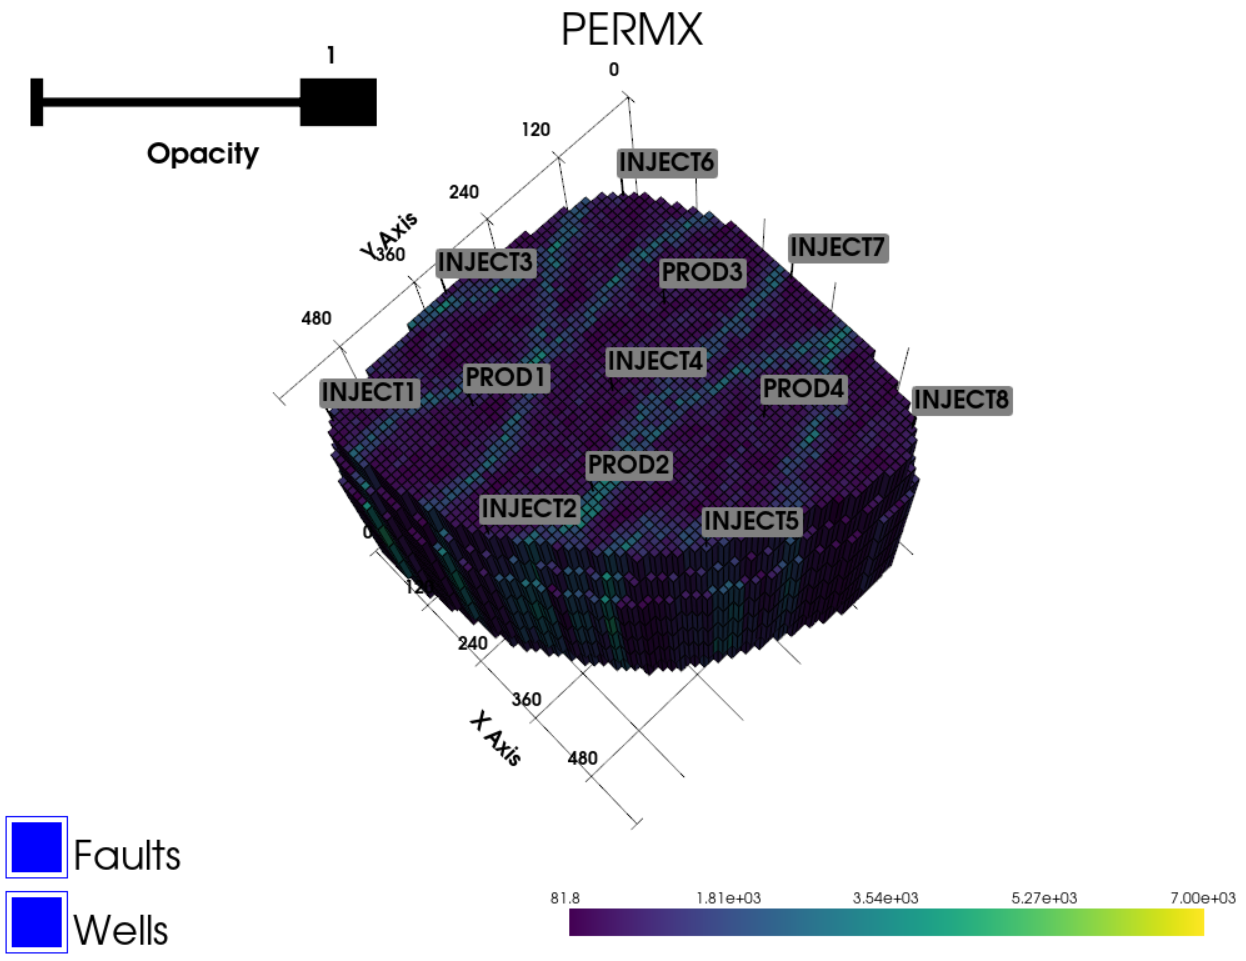</p>

Now consider what is inside the `Field`.

`Field` contains data in two formats:
* all textual data are stored in `._data` attribute as a dict structure with raw strings, numpy arrays or pandas dataframes;
* supported keywords are processed to give them a more representative form and distributed among the attributes and components of the `Field` class.

Top-level keys in `._data` correspond to sections of the .DATA file:

In [3]:
model._data.keys()

dict_keys(['', 'RUNSPEC', 'GRID', 'PROPS', 'REGIONS', 'SOLUTION', 'SUMMARY', 'SCHEDULE'])

Each section is stored as a list of keyword and raw values. For example, the GRID section of the Egg model contains the following data:

In [4]:
model._data['GRID']

[('SPECGRID',
     NX  NY  NZ  NRES COORDINATE_SYSTEM
  0  60  60   7     1                 F),
 ('ACTNUM',
  array([False, False, False, ..., False, False, False], shape=(25200,))),
 ('DX', array([8., 8., 8., ..., 8., 8., 8.], shape=(25200,))),
 ('DY', array([8., 8., 8., ..., 8., 8., 8.], shape=(25200,))),
 ('DZ', array([4., 4., 4., ..., 4., 4., 4.], shape=(25200,))),
 ('TOPS',
  array([4000., 4000., 4000., ..., 4024., 4024., 4024.], shape=(25200,))),
 ('PERMX',
  array([1288.7,  632.8,  309.5, ...,  786.5,  652.5,  822. ],
        shape=(25200,))),
 ('COPY',
    SOURCE   DEST  IMIN  IMAX  JMIN  JMAX  KMIN  KMAX
  0  PERMX  PERMY     1    60     1    60     1     7
  1  PERMX  PERMZ     1    60     1    60     1     7),
 ('MULTIPLY',
       ARR  MULTIPLYER  IMIN  IMAX  JMIN  JMAX  KMIN  KMAX
  0  PERMZ         0.1     1    60     1    60     1     7),
 ('NTG', array([1., 1., 1., ..., 1., 1., 1.], shape=(25200,))),
 ('PORO', array([0.2, 0.2, 0.2, ..., 0.2, 0.2, 0.2], shape=(25200,))),


More details on the raw data representation see in the [GeoRead](https://github.com/geo-kit/GeoRead) repository.

Processed data are distributed between components of the `Field`:

In [5]:
model.components

('grid', 'rock', 'states', 'wells', 'tables', 'faults')

and attributes of the components:

In [6]:
model.grid.attributes

('DIMENS', 'ACTNUM', 'ZCORN', 'COORD', 'DX', 'DY', 'DZ', 'TOPS')

Specifically:
* `grid` contains description of the orthogonal or corner-point grid;
* `rock` contains 3D arrays of petrophysical properties;
* `states` contains 4D arrays of simulated dynamic (if available);
* `wells` contains wells specification and flow rates (if available);
* `tables` contains PVT propetries;
* `faults` contains location of faults.

Consider each components more detailed.

## Grid

There are two types of  supported grid formts:
* orthogonal grid
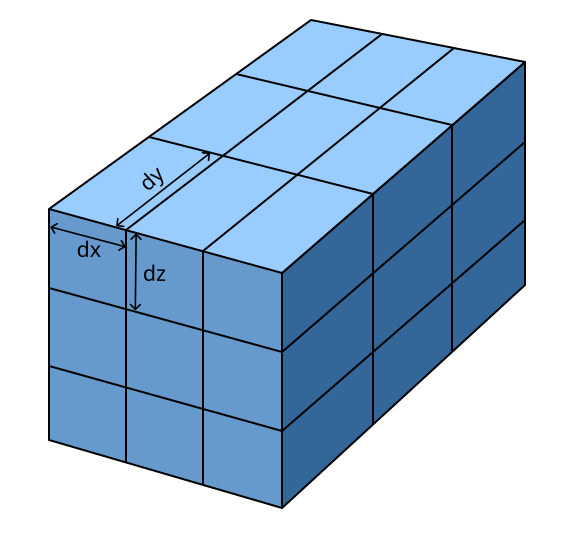

* corner-point grid 
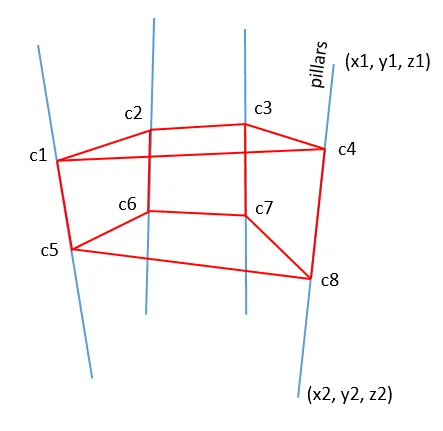

For example, the grid in the Egg model is orthogonal:

In [7]:
model.grid

Attribute DIMENS contains the number of cells in each spatial direction:

In [8]:
model.grid.DIMENS

,NX,NY,NZ
0,60,60,7


```
Note you can get attributes using UPPERCASE (model.grid.DIMENS) or lowercase (model.grid.dimens) names.
```

Attributes DX, DY, DZ contain sizes of each grid cell:

In [9]:
model.grid.DX.shape

(60, 60, 7)

Attributes ZCORN and COORD are added automatically to unify some operations on orthogonal grids with corner-point grids.

An example of the corner-point grid can be found in the [Norne](https://github.com/OPM/opm-data/tree/master/norne.) reservoir model.

Also, orthogonal grids can be represented as the corner-point grid:

In [10]:
model.grid.as_corner_point

Attributes ZCORN and COORD has the proper spatial form:

In [11]:
model.grid.as_corner_point.zcorn.shape, model.grid.as_corner_point.coord.shape

((60, 60, 7, 8), (61, 61, 6))

Regardless of grid type, the attribute ACTNUM contains binary mask of active cells:


In [12]:
model.grid.ACTNUM.shape, model.grid.ACTNUM.dtype

((60, 60, 7), dtype('bool'))

Also, for each grid type, one can compute:
* bounding box containing all grid cells

In [13]:
model.grid.bounding_box

array([   0.,    0., 4000.,  480.,  480., 4028.])

* cells volumes for active cells

In [14]:
model.grid.cell_volumes

array([256., 256., 256., ..., 256., 256., 256.], shape=(18553,))

* coordinated of centers of active cells

In [15]:
model.grid.cell_centroids

array([[4.000e+00, 2.120e+02, 4.010e+03],
       [4.000e+00, 2.120e+02, 4.014e+03],
       [4.000e+00, 2.120e+02, 4.018e+03],
       ...,
       [4.760e+02, 9.200e+01, 4.014e+03],
       [4.760e+02, 9.200e+01, 4.018e+03],
       [4.760e+02, 9.200e+01, 4.022e+03]], shape=(18553, 3))

* coordinates of vertices of all cells

In [16]:
model.grid.get_xyz().shape

(60, 60, 7, 8, 3)

Note that some methods create flat arrays whose elements correspond to active cells. To determine which index in this array corresponds to which three-dimensional cell index, use `id_to_ijk`. For example, here we calculate the coordinates of the third element:

In [17]:
model.grid.id_to_ijk(3)

array([ 0, 26,  5])

For the reverse mode, use `ijk_to_id`. For example:

In [18]:
model.grid.ijk_to_id([0, 26,  5])

[np.int64(3)]

One can process grids using VTK methods. Grid component contains VTK representation of the grid as the unstructures grid:

In [19]:
model.grid.vtk_grid

<vtkmodules.vtkCommonDataModel.vtkUnstructuredGrid(0x2b5425a0) at 0x7fcd15542080>

Using the VTK interface [https://vtk.org/doc/nightly/html/classvtkUnstructuredGrid.html](https://vtk.org/doc/nightly/html/classvtkUnstructuredGrid.html), one can manpulate with VTK grid. For example:

In [20]:
model.grid.vtk_grid.GetNumberOfPoints(), model.grid.vtk_grid.GetNumberOfCells()

(29768, 18553)

Note a few differences when using VTK interface and GeoCode interface.

First, `vtk_grid` contains only active cells. For example, vertices of the first active cell are

In [21]:
from vtkmodules.util.numpy_support import vtk_to_numpy

vtk_to_numpy(model.grid.vtk_grid.GetCell(0).GetPoints().GetData())

array([[   0.,  208., 4008.],
       [   8.,  208., 4008.],
       [   8.,  216., 4008.],
       [   0.,  216., 4008.],
       [   0.,  208., 4012.],
       [   8.,  208., 4012.],
       [   8.,  216., 4012.],
       [   0.,  216., 4012.]])

To get vertices of this cell using `get_xyz`, we need to map index of the active cell to the three-dimensional indices:

In [22]:
model.grid.get_xyz()[*model.grid.id_to_ijk(0)]

array([[   0.,  208., 4008.],
       [   8.,  208., 4008.],
       [   0.,  216., 4008.],
       [   8.,  216., 4008.],
       [   0.,  208., 4012.],
       [   8.,  208., 4012.],
       [   0.,  216., 4012.],
       [   8.,  216., 4012.]])

Second, note that the order of vertices in VTK and `get_xyz` is different.  The order in `get_xyz` is
```
   2 -- 3
  /|   /|
0 -- 1  |
|  | |  |
|  6 -- 7
| /  | /
4 -- 5
```
While the order in VTK is
```
   3 -- 2
  /|   /|
0 -- 1  |
|  | |  |
|  7 -- 6
| /  | /
4 -- 5
```

## Rock and States

These components contain properties of grid cells. Static properties are in the `rock` component:

In [23]:
model.rock.attributes

('PORO', 'PERMX', 'PERMY', 'PERMZ')

Dynamic properties are in the `states` component:

In [24]:
model.states.attributes

('PRESSURE', 'SOIL', 'SWAT')

Attributes in `rock` are 3D arrays, attributes in `states` are 4D arrays:

In [27]:
model.rock.PORO.shape, model.states.PRESSURE.shape

((60, 60, 7), (121, 60, 60, 7))

Both components have an interactive `show_slice` method to visualize slices of the selected property:

```python
model.rock.show_slice(attr='permx', figsize=(10, 8), cmap='rainbow')
```

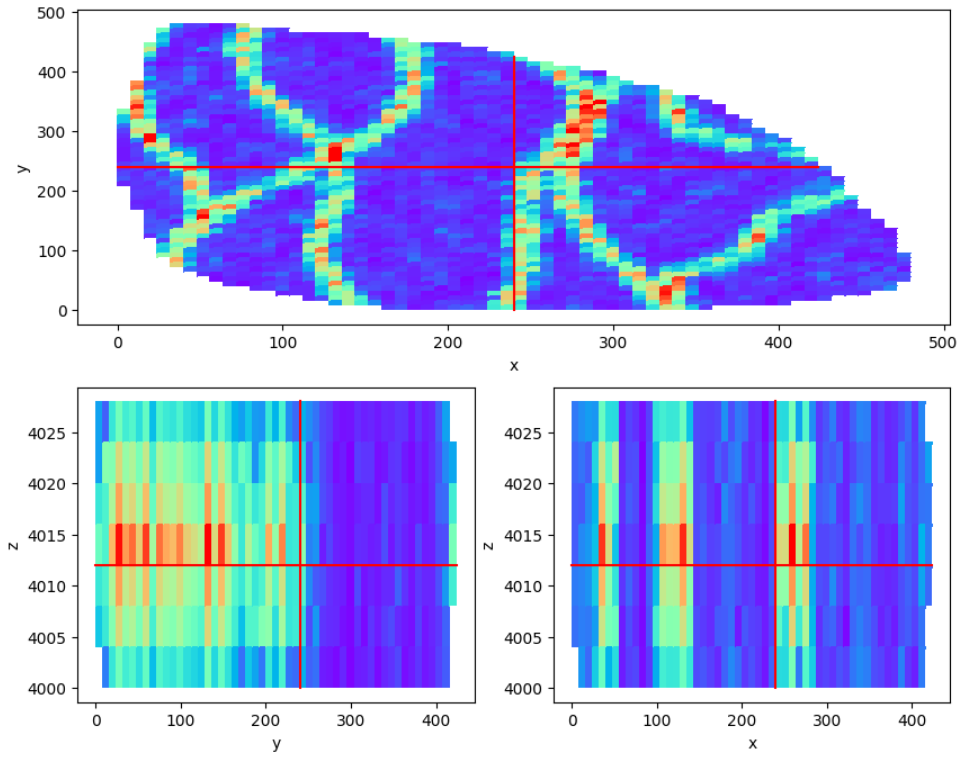

## Wells

This component contains well coordinates and production flow rates (if available). 
All data can be access as attributes of the `wells` component:

In [31]:
model.wells.attributes

('WELSPECS', 'WCONPROD', 'WCONINJE', 'COMPDAT', 'WELLTRACK', 'RESULTS')

Each attribute is a pandas dataframe. For example:

In [33]:
model.wells.WELSPECS

,WELL,GROUP,IW,JW,REF_DEPTH,PHASE,DRAINAGE_RADIUS,INFLOW_EQUATION_FLAG,SHUT_OR_STOP,CROSFLOW_ABILITY_FLAG,PRESSURE_TABLE_NUMBER,DENSITY_CALCULATION_TYPE,PRESSURE_RETRIEVING
0,INJECT1,1,5,57,NaN,WATER,NaN,None,None,None,-99999999,None,None
1,INJECT2,1,30,53,NaN,WATER,NaN,None,None,None,-99999999,None,None
2,INJECT3,1,2,35,NaN,WATER,NaN,None,None,None,-99999999,None,None
3,INJECT4,1,27,29,NaN,WATER,NaN,None,None,None,-99999999,None,None
4,INJECT5,1,50,35,NaN,WATER,NaN,None,None,None,-99999999,None,None
5,INJECT6,1,8,9,NaN,WATER,NaN,None,None,None,-99999999,None,None
6,INJECT7,1,32,2,NaN,WATER,NaN,None,None,None,-99999999,None,None
7,INJECT8,1,57,6,NaN,WATER,NaN,None,None,None,-99999999,None,None
8,PROD1,1,16,43,NaN,OIL,NaN,None,None,None,-99999999,None,None
9,PROD2,1,35,40,NaN,OIL,NaN,None,None,None,-99999999,None,None


Using the well name, one can access attributes and production rates of a specific well. For example:

In [40]:
model.wells['PROD1'].RESULTS

,DATE,WELL,WLPR,WOPR,WWIR,WWPR
8,2011-06-15,PROD1,0.000000,0.000000,NaN,0.000000
20,2011-07-15,PROD1,131.873627,131.873627,NaN,0.000000
32,2011-08-14,PROD1,132.573273,132.573273,NaN,0.000000
44,2011-09-13,PROD1,132.983170,132.983170,NaN,0.000000
56,2011-10-13,PROD1,133.484787,133.484787,NaN,0.000000
...,...,...,...,...,...,...
1400,2020-12-24,PROD1,134.935532,2.330047,NaN,132.605484
1412,2021-01-23,PROD1,134.886490,2.304971,NaN,132.581528
1424,2021-02-22,PROD1,134.839066,2.280370,NaN,132.558685
1436,2021-03-24,PROD1,134.792755,2.256245,NaN,132.536514


Full list of well names is accessed using  attribute `names`:

In [35]:
model.wells.names

['INJECT1',
 'INJECT2',
 'INJECT3',
 'INJECT4',
 'INJECT5',
 'INJECT6',
 'INJECT7',
 'INJECT8',
 'PROD1',
 'PROD2',
 'PROD3',
 'PROD4']

Using `render_tree`, one can visualize the group structure of the wells:

In [36]:
model.wells.render_tree()

FIELD
+-- 1
    |-- INJECT1
    |-- INJECT2
    |-- INJECT3
    |-- INJECT4
    |-- INJECT5
    |-- INJECT6
    |-- INJECT7
    |-- INJECT8
    |-- PROD1
    |-- PROD2
    |-- PROD3
    +-- PROD4


Method `show_wells` provides a simple visualization of well trajectories:

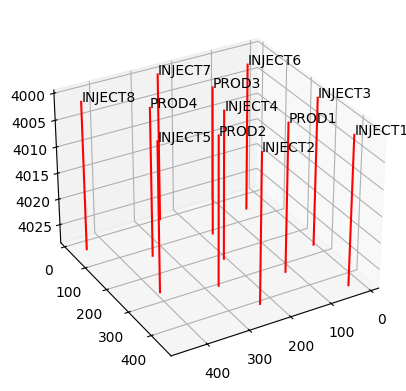

In [37]:
model.wells.show_wells()

Method `show_rates` provies an interactive visualization of production rates:
```python
model.wells.show_rates()
```

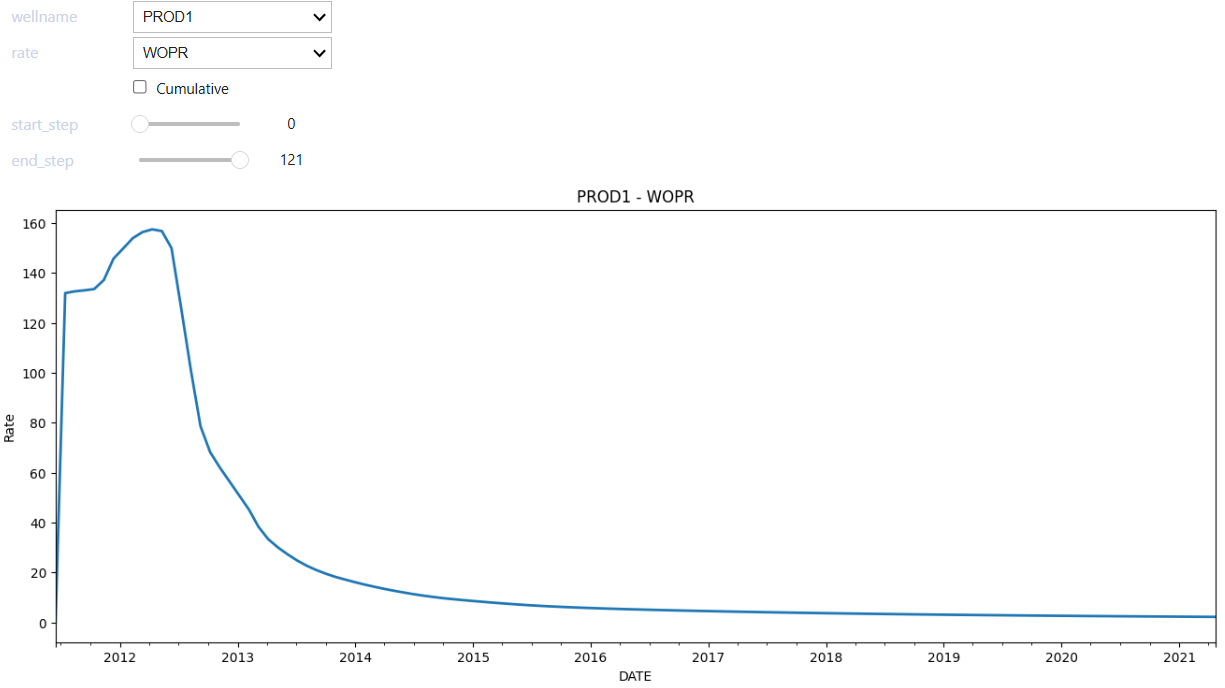

In order to connect the well trajectory with grid cells, use `get_blocks` method:

In [43]:
model.wells.get_blocks()

Now one can get a list of active grid cells indersected by the well trajectory. For example:

In [44]:
model.wells['PROD1'].blocks

array([[15, 42,  3],
       [15, 42,  6],
       [15, 42,  5],
       [15, 42,  2],
       [15, 42,  1],
       [15, 42,  4],
       [15, 42,  0]])

## Faults

This component is logically similar with the `wells` component. Use, for example, the [Norne](https://github.com/OPM/opm-data/tree/master/norne.) reservoir model to explore its functionality.

More examples of application of the GepCode are coming soon.